In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from Pretraining_CNN_triplet_helper import*

2026-05-29 16:02:32.973357: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-29 16:02:33.080479: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 16:02:33.084394: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-29 16:02:33.084406: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if yo

In [4]:
class Predictions:
    
    def __init__(self, path_val_test_samples, path_val_pairs, path_tests, p_arrays, path_preds, shp, bs):
        self.path_val_test_samples = path_val_test_samples
        self.path_tests = path_tests
        self.path_val_pairs = path_val_pairs
        self.n1_test = self.path_tests+"n1_test_pairs.csv"
        self.n2_test = self.path_tests+"n2_test_pairs.csv"
        self.n3_test = self.path_tests+"n3_test_pairs.csv"
        self.n1_n2_test = self.path_tests+"n1_n2_test_pairs.csv"
        self.n1_n3_test = self.path_tests+"n1_n3_test_pairs.csv"
        self.n2_n3_test = self.path_tests+"n2_n3_test_pairs.csv"
        self.p_arrays = p_arrays
        self.path_preds = path_preds
        self.bs = bs
        self.shp = shp
        self.evaluator = None
        self.model = None
        
    def evaluation_samples(self, path):
        n1_v = pd.read_csv(path+"n1_validation.csv")
        n1_t = pd.read_csv(path+"n1_test.csv")
        n2_t = pd.read_csv(path+"n2_test.csv")
        n3_t = pd.read_csv(path+"n3_test.csv")
        df =  pd.concat([n1_v, n1_t, n2_t, n3_t])
        return df.Segment.values
    
    def sample_to_embedding(self, val_test_samples):
        testgen = TestGe(val_test_samples, self.shp, self.bs, self.p_arrays)
        embeddings = model.predict(testgen,verbose=1 )
        return {val_test_samples[i]:embeddings[i] for i in range(len(val_test_samples))}
    
    def optimal_threshold(self, p_val_pairs, sample_2_emb_dict, night):
        
        df_val_pairs = pd.read_csv(p_val_pairs)
        samples_1 = df_val_pairs.sample_1.values
        samples_2 = df_val_pairs.sample_2.values
        labels = df_val_pairs.label.values
        
        embeds_1 = np.array([sample_2_emb_dict[samples_1[i]] for i in range(len(samples_1))])
        embeds_2 = np.array([sample_2_emb_dict[samples_2[i]] for i in range(len(samples_2))])
        
        pre, rec, f1s, acc, thr, dist, preds = self.evaluator.evaluation_metrics(embeds_1, embeds_2, labels, night)
        
        df_val_pairs["Euclid_dist"] = dist
        df_val_pairs["Threshold"] = [thr]*(len(embeds_1))
        df_val_pairs["Predictions"] = preds
        df_val_pairs.to_csv(self.path_preds+night+".csv", index = False)
        
        return pre, rec, f1s, acc, thr
    
    def test_predictions(self, p_test_pairs, sample_2_embed, thr, night = None):
        
        df_test_pairs = pd.read_csv(p_test_pairs)
        samples_1 = df_test_pairs.sample_1.values
        samples_2 = df_test_pairs.sample_2.values
        
        labels = df_test_pairs.label.values
        
        embeds_1 = np.array([sample_2_embed[samples_1[i]] for i in range(len(samples_1))])
        embeds_2 = np.array([sample_2_embed[samples_2[i]] for i in range(len(samples_2))])
        
        P, R, F, A, pair_wise_dists, preds = self.evaluator.mymetrics(embeds_1, embeds_2, labels, thr, night)
        
        df_test_pairs["Euclid_dist"] = pair_wise_dists
        df_test_pairs["Threshold"] = [thr]*(len(embeds_1))
        df_test_pairs["Predictions"] = preds
        df_test_pairs.to_csv(self.path_preds+night+".csv", index = False)
        
        return P, R, F, A
    
    def Execution(self):
        
        val_test_samples = self.evaluation_samples(self.path_val_test_samples)
        sample_2_embedding = self.sample_to_embedding(val_test_samples)
        pre, rec, f1s, acc, thr = self.optimal_threshold(self.path_val_pairs, sample_2_embedding, "n1_val")
        
        p1, r1, f1, a1 = self.test_predictions(self.n1_test, sample_2_embedding, thr, "n1_test")
        p2, r2, f2, a2 = self.test_predictions(self.n2_test, sample_2_embedding, thr, "n2_test")
        p3, r3, f3, a3 = self.test_predictions(self.n3_test, sample_2_embedding, thr, "n3_test")
        p12, r12, f12, a12 = self.test_predictions(self.n1_n2_test, sample_2_embedding, thr, "n1_n2_test")
        p13, r13, f13, a13 = self.test_predictions(self.n1_n3_test, sample_2_embedding, thr, "n1_n3_test")
        p23, r23, f23, a23 = self.test_predictions(self.n2_n3_test, sample_2_embedding, thr, "n2_n3_test")
        
        metrics = {"n1v":[pre, rec, f1s, acc],
                   "n11":[p1,r1,f1,a1],
                   "n22":[p2, r2, f2, a2],
                   "n33":[p3, r3, f3, a3],
                   "n12":[p12, r12, f12, a12],
                   "n13":[p13, r13, f13, a13],
                   "n23":[p23, r23, f23, a23]
                  }
        
        df = pd.DataFrame.from_dict(metrics, orient = "index", columns = ["precision","recall","f1_score","accuracy"])
        df = df.rename_axis("nights")
        df.to_csv(self.path_preds+"metrics.csv")
        
        print("Evaluation has finished")
        return df
   

Training has started
Epoch 1/2
7/7 [==============================] - 55s 8s/step - loss: 1.0235 - val_loss: 1.0176 - lr: 0.0010
Epoch 2/2
7/7 [==============================] - 52s 7s/step - loss: 1.0235 - val_loss: 1.0176 - lr: 0.0010
Loading best model weights
Validation loss : 1.017642855644226
15/15 [==============================] - 78s 5s/step
Evaluation has finished


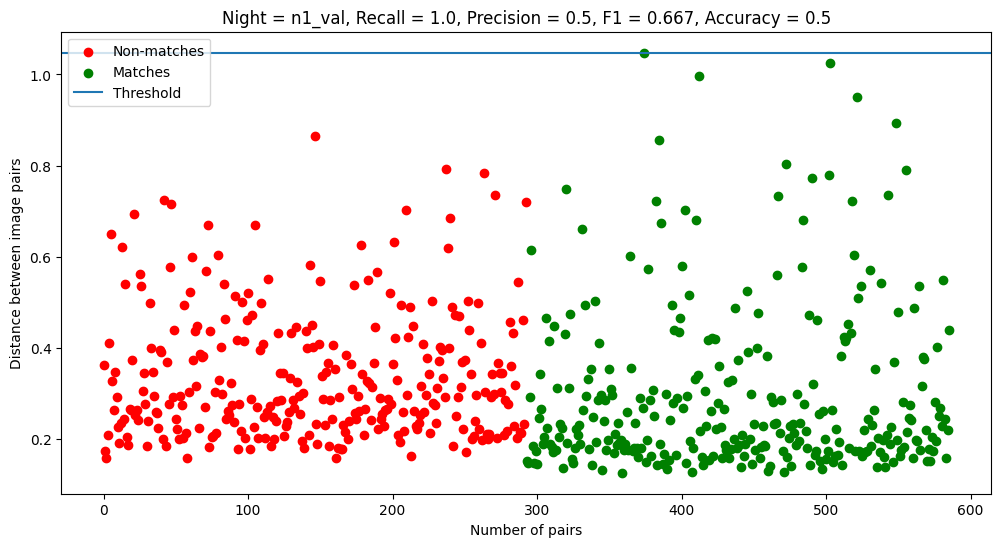

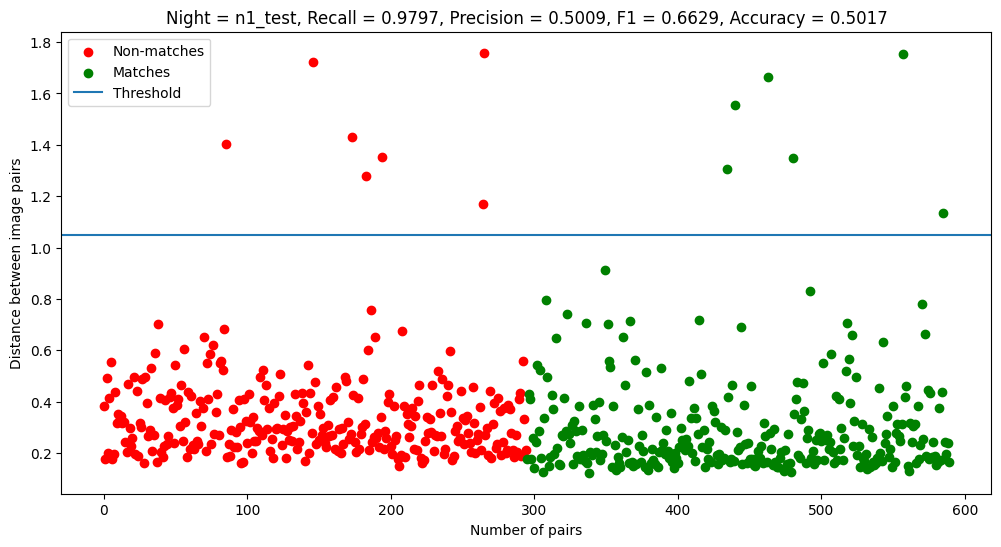

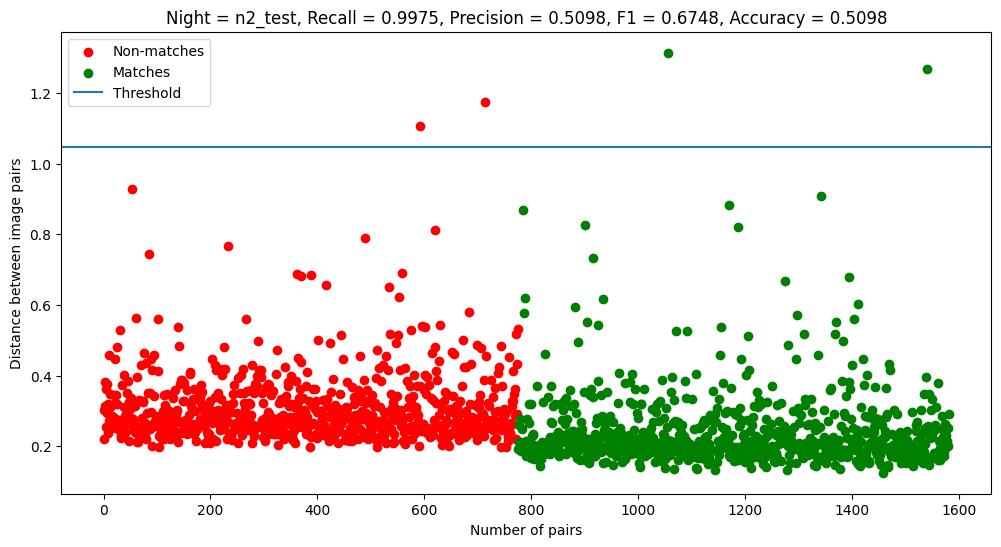

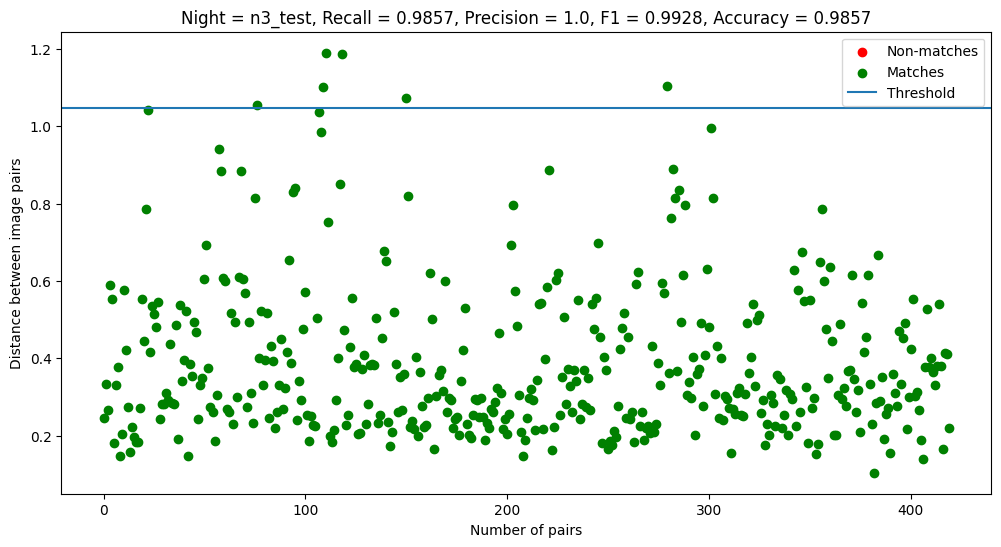

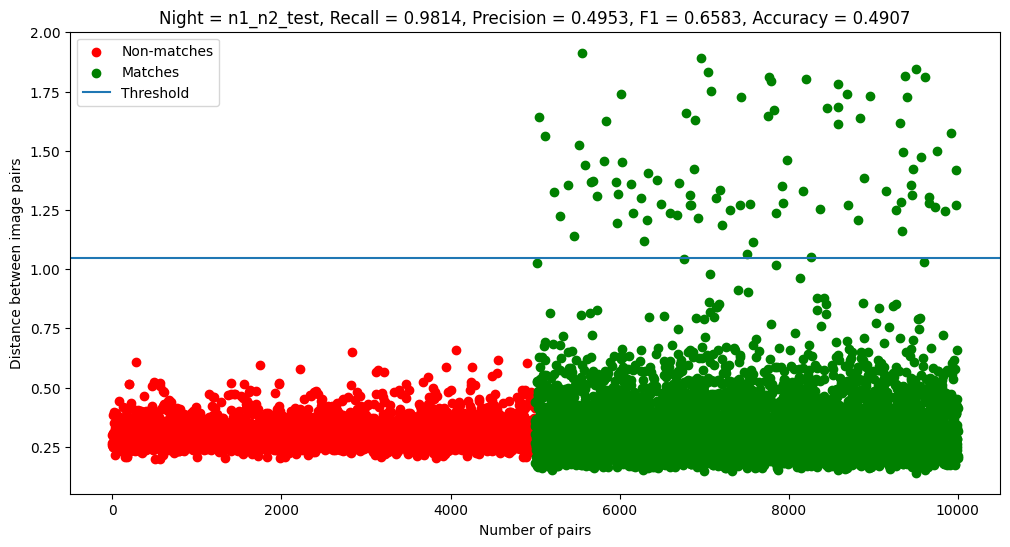

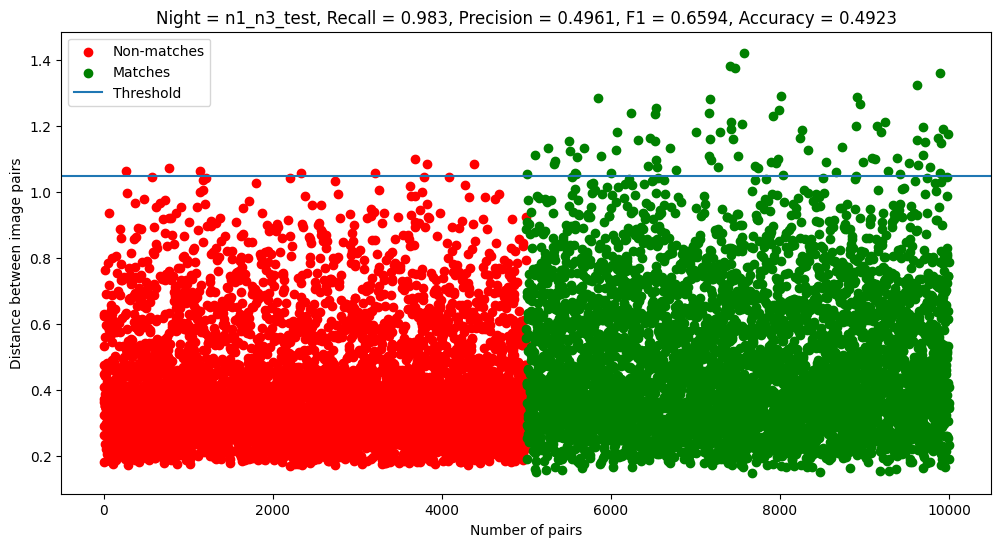

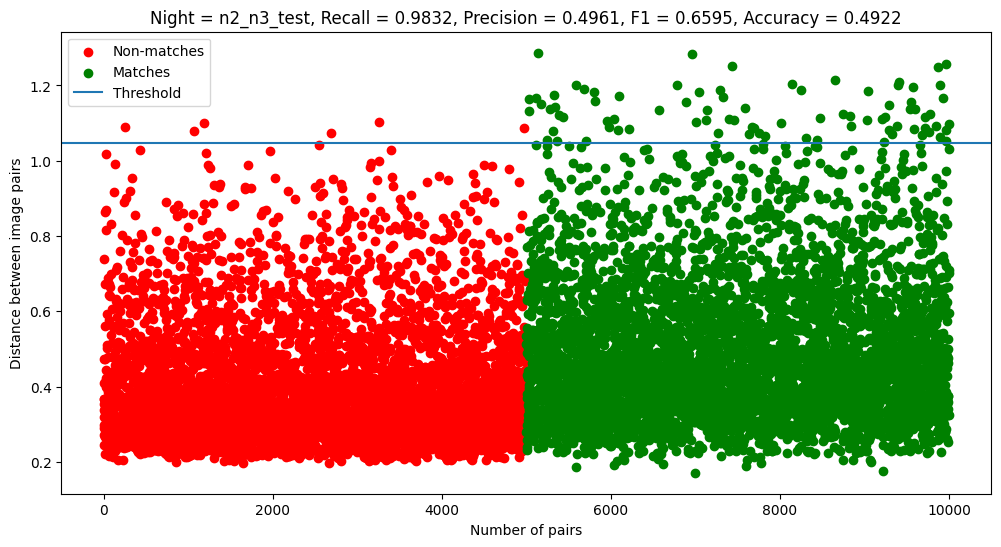

In [11]:
if __name__ == "__main__":

    # ==================================================
    # Training parameters
    # ==================================================
    Lr = 1e-3
    lr = 1e-5
    Epochs = 2
    shp = (224, 224, 3)
    pretrained = False
    finetune = False
    batch_size = 128
    samples_per_ID = 16
    # ==================================================
    # Paths
    # ==================================================  
    # Training and validation metadata
    p_train = f"../closed_population_ID/train_val_test_segment_data/n1_train.csv"
    p_validation = f"../closed_population_ID/train_val_test_segment_data/n1_validation.csv"
    p_arrays = f"../segment_spectrogram_mfcc_feature_extraction/spectrogram_arrays/"
    p_weights = f"weights/pre_weights.h5"
    p_s = f"../closed_population_ID/train_val_test_segment_data/"
    p_te = f"../open_population_ID/pairs/"
    p_va = f"{p_te}n1_validation_pairs.csv"
    p_predictions = f"predictions/"
    # ==================================================
    # Data loading
    # ==================================================
    loader = DataLoader(p_train, p_validation, samples_per_ID)
    Ts, TYs, Vs, VYs = loader.train_validation_samples_labels()
    # ==================================================
    # Generators
    # ==================================================
    Tgenerator = Generator(Ts, TYs, shp, batch_size, p_arrays)
    Vgenerator = Generator(Vs, VYs, shp, batch_size, p_arrays)
    # ==================================================
    # Model architecture
    # ==================================================
    architecture = CricketEmbedding(input_shape=shp, use_pretrained=pretrained, fine_tune=finetune)
    # ==================================================
    # Training
    # ==================================================
    trainer = Training()
    trainer.architecture = architecture
    trainer.Tgenerator = Tgenerator
    trainer.Vgenerator = Vgenerator
    model, history = trainer.train(Lr, lr, p_weights, Epochs)
    # ==================================================
    # Evaluation and prediction
    # ==================================================
    evaluator = Evaluation()
    predictor = Predictions(p_s, p_va, p_te, p_arrays, p_predictions, shp, batch_size)
    predictor.model = model
    predictor.evaluator = evaluator

    df = predictor.Execution()